In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import requests
import time
from time import sleep

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [2]:
import numpy as np
np.set_printoptions(threshold=np.inf)

In [3]:
api_root = "https://data.ademe.fr/data-fair/api/v1/datasets/dpe02neuf/lines?etiquette_dpe_eq=F&page=1&size=100"

response = requests.get(api_root)
print(response)


if response.status_code == 200:
    data = response.json()
    print(data["results"])

df = pd.DataFrame(data["results"])


<Response [200]>
[{'score_ban': 0.97, 'conso_auxiliaires_ep': 1478, 'deperditions_murs': 104, 'cout_eclairage': 330, 'conso_auxiliaires_ef': 642, 'statut_geocodage': 'adresse non géocodée ban car aucune correspondance trouvée', 'ventilation_posterieure_2012': 0, 'cout_chauffage': 2325, 'conso_5_usages_par_m2_ep': 388.9, 'date_etablissement_dpe': '2022-04-03', 'conso_ecs_ef_energie_n1': 9878, 'emission_ges_chauffage': 5956, 'qualite_isolation_plancher_haut_comble_amenage': 'moyenne', 'conso_5_usages_par_m2_ef': 362.2, 'conso_chauffage_ef_energie_n1': 26342, 'presence_brasseur_air': 1, 'qualite_isolation_menuiseries': 'très bonne', 'date_reception_dpe': '2022-04-03', 'cout_total_5_usages_energie_n1': 3860, 'cout_ecs_energie_n1': 1019, 'qualite_isolation_plancher_bas': 'très bonne', 'isolation_toiture': 1, 'modele_dpe': 'DPE NEUF logement : RT2012', 'qualite_isolation_enveloppe': 'très bonne', 'type_energie_n1': 'Électricité', 'emission_ges_eclairage': 89, 'code_postal_ban': '42300', 'emi

In [4]:
response.json()["total"]

90

In [5]:
columns = ['numero_dpe',
    
    'classe_altitude', 'zone_climatique',
           'annee_construction', 'periode_construction',
           'surface_habitable_logement', 'type_batiment',

           'type_energie_n1', 
           'type_energie_n2',
            #'type_energie_principale_ecs', 

           'cout_chauffage', 
           #'besoin_ecs_logement',
           'cout_total_5_usages',

           'qualite_isolation_enveloppe', 
           'qualite_isolation_plancher_bas',
           'qualite_isolation_menuiseries',
           #'isolation_toiture',
           'qualite_isolation_plancher_haut_comble_amenage', 
           
           # To predict
           'emission_ges_5_usages_par_m2',
           'conso_5_usages_par_m2_ep',
           'conso_5_usages_par_m2_ef',
           'etiquette_dpe', 'etiquette_ges',]
df[columns]

,numero_dpe,classe_altitude,zone_climatique,annee_construction,periode_construction,surface_habitable_logement,type_batiment,type_energie_n1,type_energie_n2,cout_chauffage,cout_total_5_usages,qualite_isolation_enveloppe,qualite_isolation_plancher_bas,qualite_isolation_menuiseries,qualite_isolation_plancher_haut_comble_amenage,emission_ges_5_usages_par_m2,conso_5_usages_par_m2_ep,conso_5_usages_par_m2_ef,etiquette_dpe,etiquette_ges
0,2242N0685593Z,inférieur à 400m,H1c,2021,2013-2021,NaN,maison,Électricité,NaN,2325.0,3860.0,très bonne,très bonne,très bonne,moyenne,78.9,388.9,362.2,F,F
1,2678N0223755N,NaN,NaN,2026,après 2021,40.4,appartement,Réseau de Chauffage urbain,Électricité,1054.4,1249.2,très bonne,bonne,très bonne,NaN,3.2,340.8,338.1,F,A
2,2220N0187156M,inférieur à 400m,H3,2022,2013-2021,74.3,appartement,Électricité,NaN,151.0,2175.0,très bonne,très bonne,très bonne,moyenne,5.8,342.8,329.1,F,B
3,2191N0219948K,NaN,NaN,2021,2013-2021,200.7,immeuble,Réseau de Chauffage urbain,Électricité,3965.0,6406.0,insuffisante,bonne,très bonne,NaN,51.5,378.0,347.6,F,E
4,2144N0354155K,NaN,NaN,2021,2013-2021,31.3,appartement,Réseau de Chauffage urbain,Électricité,499.0,986.0,moyenne,bonne,très bonne,NaN,27.6,367.4,356.7,F,C
5,2187N0237679F,NaN,NaN,2021,2013-2021,2357.0,immeuble,Électricité,NaN,2253.0,82497.0,très bonne,très bonne,moyenne,NaN,14.8,413.1,217.5,F,C
6,2187N0237680G,NaN,NaN,2021,2013-2021,615.0,immeuble,Électricité,NaN,898.0,22220.0,bonne,bonne,moyenne,NaN,15.0,419.0,220.6,F,C
7,2133N0477461N,inférieur à 400m,H2c,2021,2013-2021,300.0,appartement,Électricité,NaN,29.2,11993.8,très bonne,très bonne,insuffisante,NaN,17.6,399.8,210.4,F,C
8,2238N0766538C,NaN,NaN,2022,après 2021,105.3,immeuble,Électricité,NaN,402.0,3431.0,bonne,bonne,très bonne,NaN,13.8,379.3,199.6,F,C
9,2106N0979624L,NaN,NaN,2021,2013-2021,99.1,immeuble,Électricité,NaN,215.0,3263.0,bonne,très bonne,bonne,NaN,13.5,381.2,200.7,F,C


# Fetch all data

In [6]:
def fetch_dpe_data(etiquette, page_start, page_end, columns=None):
    """
    Fetch DPE data from the API for a range of pages.
    
    Parameters:
    -----------
    page_start : int
        Starting page number
    page_end : int
        Ending page number (inclusive)
    columns : list, optional
        List of columns to fetch. If None, uses default columns.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with the fetched data
    """
    if columns is None:
        columns = ['numero_dpe',
            'classe_altitude', 'zone_climatique',
                   'annee_construction', 'periode_construction',
                   'surface_habitable_logement', 'type_batiment',
                   'type_energie_n1', 'type_energie_n2',
                   'cout_chauffage', 'cout_total_5_usages',
                   'qualite_isolation_enveloppe', 
                   'qualite_isolation_plancher_bas',
                   'qualite_isolation_menuiseries',
                   'qualite_isolation_plancher_haut_comble_amenage', 
                   'emission_ges_5_usages_par_m2',
                   'conso_5_usages_par_m2_ep',
                   'conso_5_usages_par_m2_ef',
                   'etiquette_dpe', 'etiquette_ges']
    
    api_root = "https://data.ademe.fr/data-fair/api/v1/datasets/dpe02neuf/lines"
    columns_encoded = "%2C".join(columns)
    
    results = []
    page = page_start
    
    while page <= page_end:
        url = f"{api_root}?select={columns_encoded}&size=1000&etiquette_dpe_eq={etiquette}&page={page}"
        
        response = requests.get(url)
        print(f"Page {page}: {response.status_code}")
        
        sleep(10)  # To avoid hitting the API rate limit
        
        if response.status_code == 200:
            data = response.json()
            results.extend(data['results'])
            print(f"Fetched {len(data['results'])} records from page {page}")
        else:
            print(f"Error fetching page {page}")
            break
        
        page += 1
    
    all_data = pd.json_normalize(results)
    return all_data


# # Example usage:
# # all_data = fetch_dpe_data(page_start=1, page_end=5)
# all_data = fetch_dpe_data(etiquette="A", page_start=1, page_end=20)

In [7]:
# for etiquette in ["A", "B", "C", "D", "E", "F", "G"]:
#     print(f"Fetching data for etiquette {etiquette}...")
#     all_data = fetch_dpe_data(etiquette=etiquette, page_start=1, page_end=20)
#     all_data.to_csv(f'ett_dpe_{etiquette}_1_10.csv', index=False)

# Data analysis

In [8]:
ett_A = pd.read_csv('data/ett_dpe_A_1_10.csv')
ett_B = pd.read_csv('data/ett_dpe_B_1_10.csv')
ett_C = pd.read_csv('data/ett_dpe_C_1_10.csv')
ett_D = pd.read_csv('data/ett_dpe_D_1_10.csv')
ett_E = pd.read_csv('data/ett_dpe_E_1_10.csv') 
ett_F = pd.read_csv('data/ett_dpe_F_1_10.csv')
ett_G = pd.read_csv('data/ett_dpe_G_1_10.csv')     

In [9]:
df_all = pd.concat([ett_A, ett_B, ett_C, ett_D, ett_E, ett_F, ett_G], ignore_index=True)
df_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 33746 entries, 0 to 33745
Data columns (total 21 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   conso_5_usages_par_m2_ef                        33746 non-null  float64
 1   annee_construction                              33746 non-null  int64  
 2   emission_ges_5_usages_par_m2                    33746 non-null  float64
 3   type_batiment                                   33746 non-null  str    
 4   classe_altitude                                 13316 non-null  str    
 5   periode_construction                            33746 non-null  str    
 6   numero_dpe                                      33746 non-null  str    
 7   qualite_isolation_menuiseries                   33746 non-null  str    
 8   qualite_isolation_plancher_bas                  33720 non-null  str    
 9   cout_total_5_usages                             33

In [10]:
col_to_keep = ['numero_dpe',
    
            'classe_altitude', 'zone_climatique',

           'annee_construction', 'periode_construction',
           'surface_habitable_logement', 'type_batiment',

           'type_energie_n1', 
            'type_energie_n2',
            'type_energie_principale_ecs', 

           'cout_chauffage', 
           'besoin_ecs_logement',
           'cout_total_5_usages',

           'qualite_isolation_enveloppe', 
           'qualite_isolation_plancher_bas',
           'qualite_isolation_menuiseries',
           'isolation_toiture',
           'qualite_isolation_plancher_haut_comble_amenage', 
           
           # To predict
           'emission_ges_5_usages_par_m2',
        #    'conso_5_usages_par_m2_ep',
           'conso_5_usages_par_m2_ef',
           'etiquette_dpe', 'etiquette_ges']



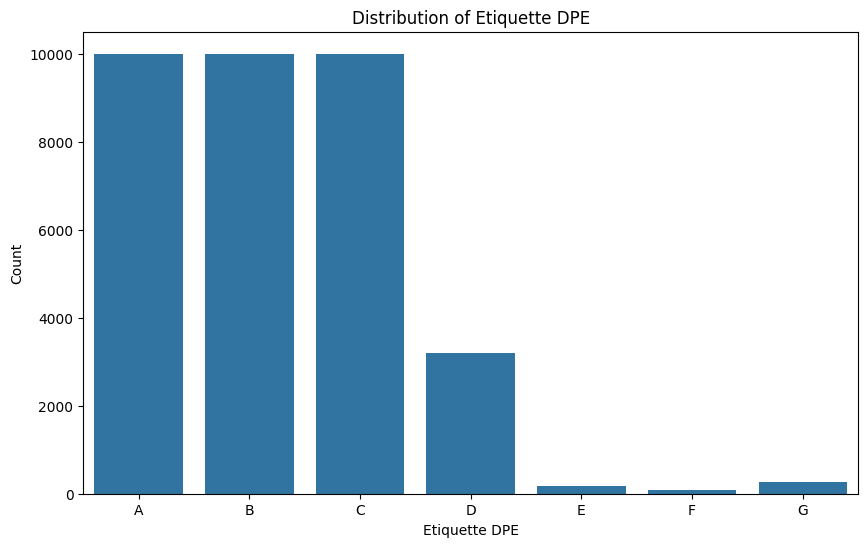

In [11]:
# Plot the distribution of the target variable 'etiquette_dpe'
plt.figure(figsize=(10, 6))
sns.countplot(x='etiquette_dpe', data=df_all, order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Distribution of Etiquette DPE')
plt.xlabel('Etiquette DPE')
plt.ylabel('Count')
plt.show()  

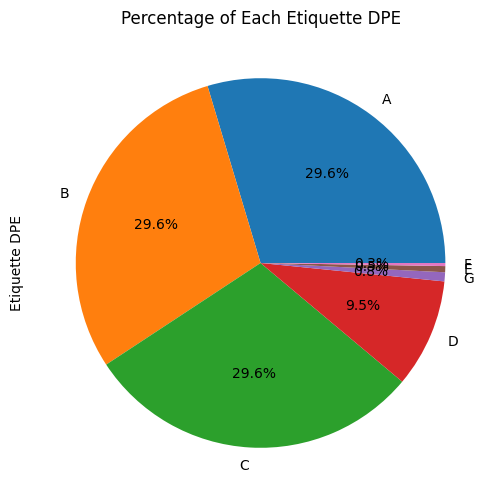

In [12]:
# Plot the percentage of the target variable 'etiquette_dpe'
etiquette_counts = df_all['etiquette_dpe'].value_counts()
plt.figure(figsize=(8, 6))
etiquette_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of Each Etiquette DPE')
plt.ylabel('Etiquette DPE')
plt.show()

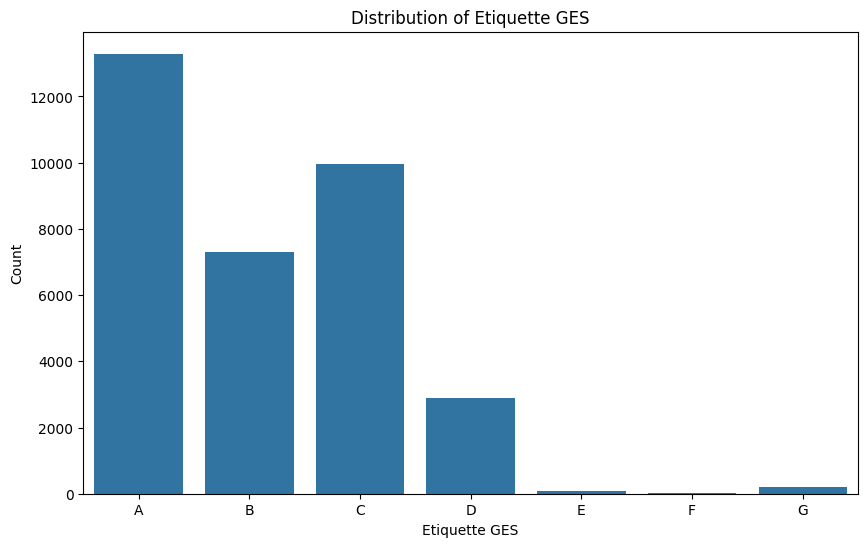

In [13]:
# Plot the distribution of the target variable 'etiquette_ges'
plt.figure(figsize=(10, 6))
sns.countplot(x='etiquette_ges', data=df_all, order=['A', 'B', 'C', 'D', 'E', 'F', 'G'])
plt.title('Distribution of Etiquette GES')
plt.xlabel('Etiquette GES')
plt.ylabel('Count')
plt.show()  

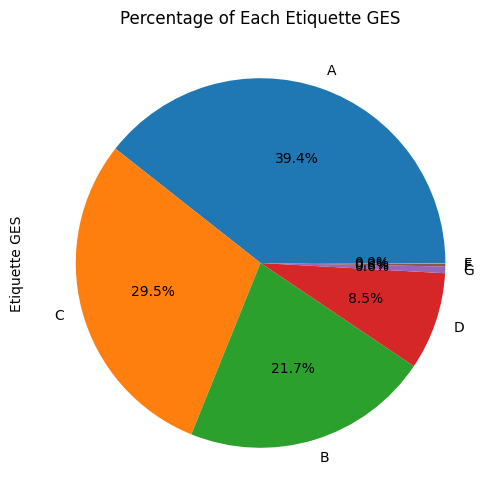

In [14]:
# Plot the percentage of the target variable 'etiquette_ges'
etiquette_counts = df_all['etiquette_ges'].value_counts()
plt.figure(figsize=(8, 6))
etiquette_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Percentage of Each Etiquette GES')
plt.ylabel('Etiquette GES')
plt.show()

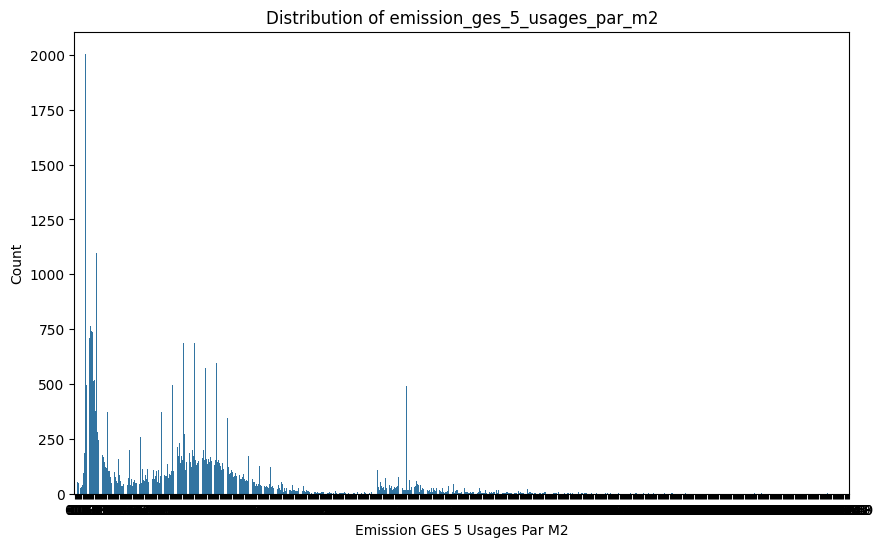

In [15]:
# Plot the distribution of the variable 'emission_ges_5_usages_par_m2'
plt.figure(figsize=(10, 6))
sns.countplot(x='emission_ges_5_usages_par_m2', data=df_all)
plt.title('Distribution of emission_ges_5_usages_par_m2')
plt.xlabel('Emission GES 5 Usages Par M2')
plt.ylabel('Count')
plt.show() 

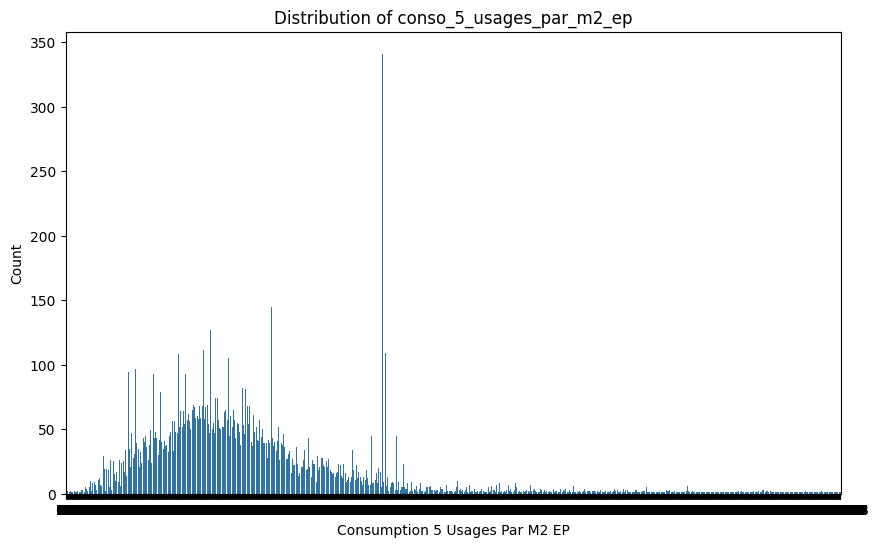

In [16]:
# Plot the distribution of the variable 'conso_5_usages_par_m2_ep'
plt.figure(figsize=(10, 6))
sns.countplot(x='conso_5_usages_par_m2_ep', data=df_all)
plt.title('Distribution of conso_5_usages_par_m2_ep')
plt.xlabel('Consumption 5 Usages Par M2 EP')
plt.ylabel('Count')
plt.show() 

# Save final data

In [17]:
from sklearn.model_selection import train_test_split


# Splitting data into features and target variable
X = df_all.drop(columns=['conso_5_usages_par_m2_ef'])

y_dpe = df_all['conso_5_usages_par_m2_ef']

X_train, X_test, y_train, y_test = train_test_split(X, y_dpe, 
                                                            test_size=0.3, 
                                                            random_state=42)

X_validation, X_test, y_validation, y_test = train_test_split(X_test, y_test,
                                                            test_size=0.5,
                                                            random_state=42)


In [18]:


X_train.to_csv('dev_phase/input_data/train/train_features.csv', index=False)
y_train.to_csv('dev_phase/input_data/train/train_labels.csv', index=False)


X_validation.to_csv('dev_phase/input_data/test/test_features.csv', index=False)
y_validation.to_csv('dev_phase/reference_data/test_labels.csv', index=False)

X_test.to_csv('dev_phase/input_data/private_test/private_test_features.csv', index=False)
y_test.to_csv('dev_phase/reference_data/private_test_labels.csv', index=False)